# Exp7.2.6.3 — Frozen-L2 Linear vs LIF decomposition
Analysis-only notebook. Reads finalized aggregate artifacts only.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root():
    p = Path.cwd().resolve()
    for q in (p, *p.parents):
        if (q / 'scripts').exists() and (q / 'notebooks').exists():
            return q
    raise FileNotFoundError('Could not find repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_6_3_linear_vs_lif_frozen_l2' / 'linear_vs_lif_frozen_l2_v1'
manifest = json.loads((ROOT / 'manifest.json').read_text())
manifest


{'architecture': '234x234',
 'cache_tasks': 3,
 'ce_logit_gain': 1.0,
 'crosscheck_tasks': 3,
 'experiment_id': 'experiment_7_2_6_3_linear_vs_lif_frozen_l2',
 'head_training_tasks': 6,
 'mechanism_tasks': 3,
 'no_e2e_retraining': True,
 'notebook_contract': 'analysis-only; reads finalized CSV/JSON artifacts only',
 'primary_input_gain': 1.0,
 'primary_question': 'Why do Linear and LIF readouts differ on the same frozen L2 sequence?',
 'protocol_version': 'linear_vs_lif_frozen_l2_v1',
 'regularization': 'task_only',
 'seeds': [11, 23, 37],
 'source': 'Exp7.2.6.1 Mean-CE bias=False task_only'}

## Mechanism ladder
Same frozen L2 and the same Exp7.2.6.1 Linear W.


,condition,n,balanced_accuracy_mean,balanced_accuracy_std
0,A0_linear_analog,3,0.545353,0.013146
1,A1_if_beta1_charge,3,0.545353,0.013146
2,A2_if_beta1_spike_count,3,0.321903,0.035217
3,A3_lif_beta05_spike_count,3,0.527769,0.019265


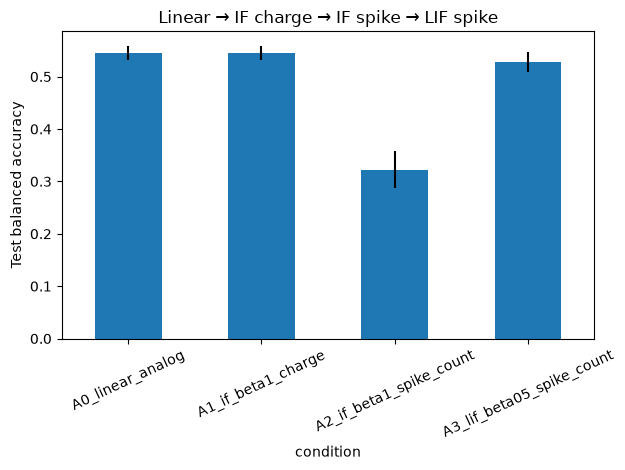

In [2]:
mechanism = pd.read_csv(ROOT / 'mechanism_summary.csv')
display(mechanism[['condition','n','balanced_accuracy_mean','balanced_accuracy_std']])
ax = mechanism.plot.bar(x='condition', y='balanced_accuracy_mean', yerr='balanced_accuracy_std', legend=False, rot=25)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Linear → IF charge → IF spike → LIF spike')
plt.tight_layout()


## Leakage curve


,beta,balanced_accuracy_mean,balanced_accuracy_std
0,0.50,0.527769,0.019265
1,0.60,0.525079,0.010507
2,0.70,0.517052,0.021991
3,0.80,0.503341,0.026030
4,0.90,0.455980,0.020578
5,0.95,0.400939,0.000743
6,1.00,0.321903,0.035217


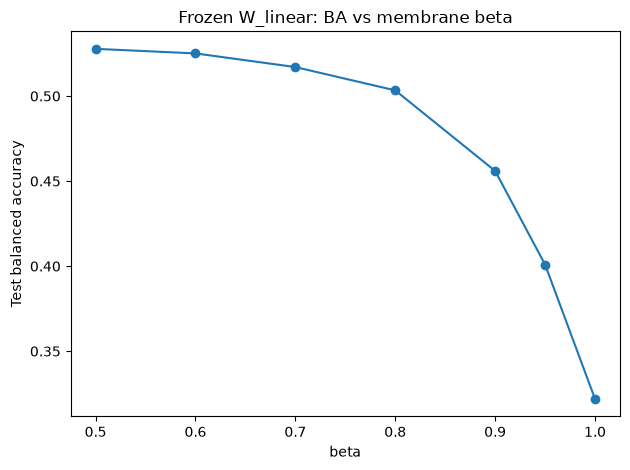

In [3]:
beta = pd.read_csv(ROOT / 'beta_sweep_summary.csv').sort_values('beta')
display(beta[['beta','balanced_accuracy_mean','balanced_accuracy_std']])
ax = beta.plot(x='beta', y='balanced_accuracy_mean', marker='o', legend=False)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Frozen W_linear: BA vs membrane beta')
plt.tight_layout()


## Paired frozen-head training
Both Linear and LIF use valid-mean CE with CE logit gain exactly 1.


In [4]:
heads = pd.read_csv(ROOT / 'head_summary.csv')
display(heads[heads['split'] == 'test'][['mode','n','balanced_accuracy_mean','balanced_accuracy_std','objective_loss_mean']])


,mode,n,balanced_accuracy_mean,balanced_accuracy_std,objective_loss_mean
0,lif,3,0.472660,0.017049,2.225335
3,linear,3,0.549818,0.021133,1.562318


## 2×2 projection × readout cross-check


,condition,n,balanced_accuracy_mean,balanced_accuracy_std
0,X1_wlin_analog,3,0.549818,0.021133
1,X2_wlin_lif_beta05,3,0.499776,0.021537
2,X3_wlif_analog,3,0.478765,0.021079
3,X4_wlif_lif_beta05,3,0.472660,0.017049


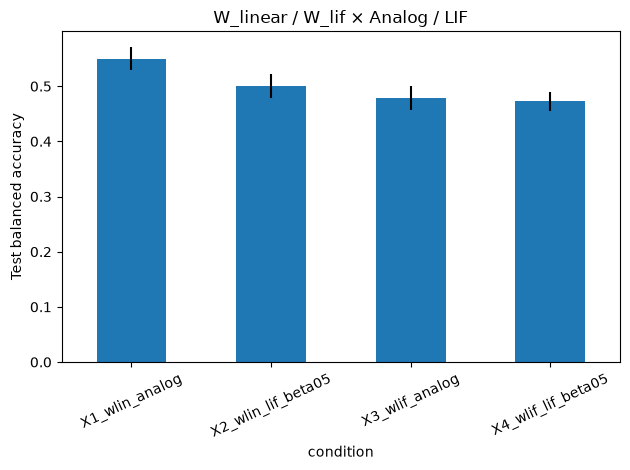

In [5]:
cross = pd.read_csv(ROOT / 'crosscheck_summary.csv')
display(cross[['condition','n','balanced_accuracy_mean','balanced_accuracy_std']])
ax = cross.plot.bar(x='condition', y='balanced_accuracy_mean', yerr='balanced_accuracy_std', legend=False, rot=25)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('W_linear / W_lif × Analog / LIF')
plt.tight_layout()


## Secondary diagnostics
Input-gain calibration, cap31 and bipolar controls are secondary and must not replace the gain=1 primary result.


In [6]:
secondary = pd.read_csv(ROOT / 'secondary_controls_summary.csv')
display(secondary[['condition','n','balanced_accuracy_mean','balanced_accuracy_std']])
decomp = pd.read_csv(ROOT / 'mechanism_decomposition_runs.csv')
cross_decomp = pd.read_csv(ROOT / 'crosscheck_decomposition_runs.csv')
display(decomp.mean(numeric_only=True).to_frame('mean_pp'))
display(cross_decomp.mean(numeric_only=True).to_frame('mean_pp'))


,condition,n,balanced_accuracy_mean,balanced_accuracy_std
0,if_beta1_bipolar_gain1,3,0.328916,0.004661
1,if_beta1_cap31_gain1,3,0.454574,0.033422
2,if_beta1_gain_calibrated,3,0.461213,0.027341
3,lif_beta05_bipolar_gain1,3,0.522897,0.020959
4,lif_beta05_cap31_gain1,3,0.496249,0.004678
5,lif_beta05_gain_calibrated,3,0.454907,0.026617


,mean_pp
seed,23.666667
charge_sanity_delta_pp,0.000000
leakage_penalty_pp,-20.586659
spike_conversion_penalty_pp,22.345039
total_linear_to_lif_pp,1.758381


,mean_pp
seed,23.666667
native_head_gap_x1_minus_x4_pp,7.715803
projection_quality_gap_x1_minus_x3_pp,7.105371
wlif_dynamics_gap_x3_minus_x4_pp,0.610431
wlin_dynamics_gap_x1_minus_x2_pp,5.004232
